In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import shap


c:\Users\Allan\Desktop\Faculdade\PISI3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('..\\datasets_paralelos\\spotify_eda_5clusters.csv')

CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'instrumentalness',
    'liveness',
]

# Box Plots

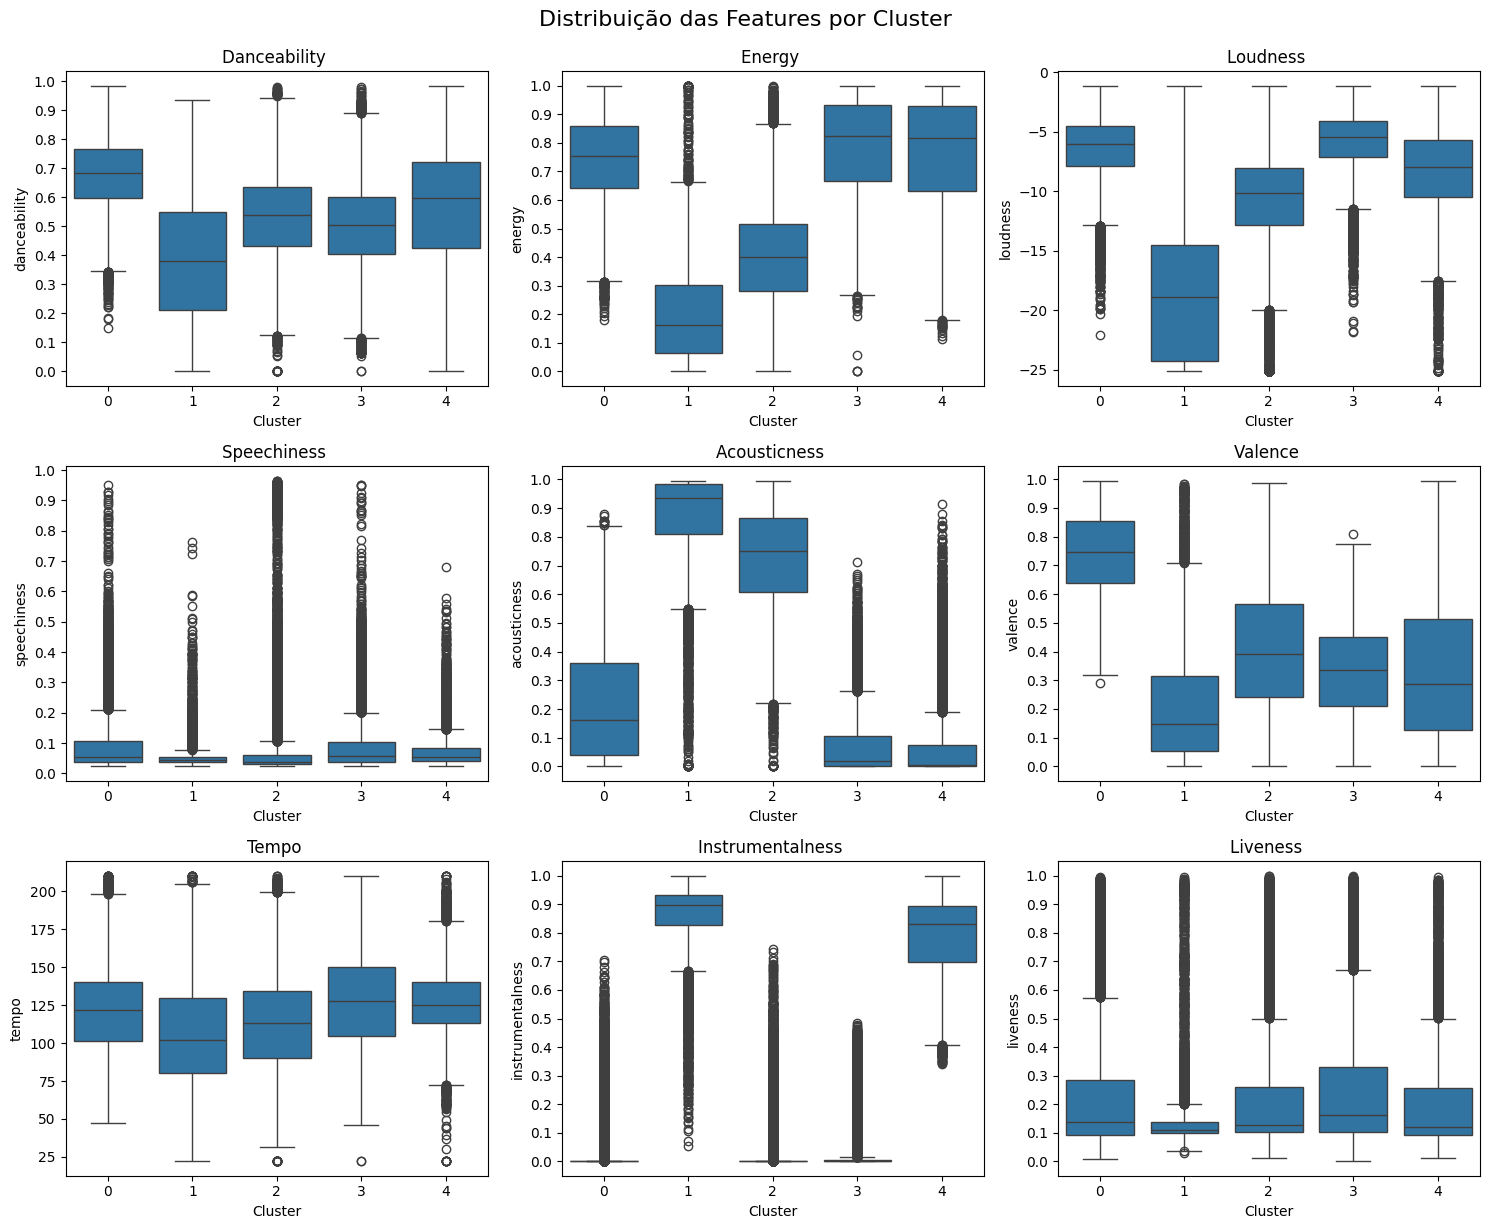

In [4]:

n_cols = 3
n_rows = (len(CLUSTER_FEATURES) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, feature in enumerate(CLUSTER_FEATURES, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(data=df, x='cluster', y=feature)
    plt.title(f'{feature.capitalize()} ')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    
    # Define ticks do eixo Y de 0.0 até 1.0 com passo 0.1 (ajuste se necessário)
    min_val = df[feature].min()
    max_val = df[feature].max()
    
    # Só aplica se o range for compatível (evita erro no loudness ou tempo)
    if max_val - min_val < 2:
        plt.yticks(np.arange(0.0, 1.05, 0.1))

plt.tight_layout()
plt.suptitle('Distribuição das Features por Cluster', fontsize=16, y=1.02)
plt.show()


# HeatMap Clusters

In [6]:
mean_per_cluster = df.groupby('cluster')[CLUSTER_FEATURES].mean()
print(mean_per_cluster)

         danceability    energy   loudness  speechiness  acousticness  \
cluster                                                                 
0            0.678811  0.739864  -6.437576     0.096141      0.219879   
1            0.392065  0.206673 -18.753727     0.054909      0.859810   
2            0.530767  0.402935 -10.793952     0.101205      0.724734   
3            0.503396  0.785658  -5.791012     0.088392      0.074368   
4            0.561568  0.764308  -8.395754     0.073670      0.075490   

          valence       tempo  instrumentalness  liveness  
cluster                                                    
0        0.740707  123.790360          0.016891  0.213373  
1        0.218765  106.141739          0.849100  0.160362  
2        0.416750  114.540311          0.020260  0.228327  
3        0.332439  129.276800          0.030679  0.246742  
4        0.341529  127.369458          0.783907  0.198585  


In [7]:
# Contagem de gêneros por cluster
genre_counts = df.groupby(['cluster', 'track_genre']).size().reset_index(name='count')

# Exibe agrupado por cluster
for c in sorted(df['cluster'].unique()):
    print(f'\n🎧 Cluster {c}:')
    
    cluster_genres = genre_counts[genre_counts['cluster'] == c].sort_values(by='count', ascending=False)
    
    # Mostra no notebook (visual bonito)
    display(cluster_genres.head(10))
    
    # Mostra como texto para copiar
    print(cluster_genres.head(10).to_string(index=False))



🎧 Cluster 0:


,cluster,track_genre,count
35,0,forro,813
95,0,salsa,759
66,0,kids,672
21,0,dancehall,632
25,0,disco,521
100,0,ska,511
1,0,afrobeat,495
78,0,party,483
77,0,pagode,458
61,0,j-idol,450


 cluster track_genre  count
       0       forro    813
       0       salsa    759
       0        kids    672
       0   dancehall    632
       0       disco    521
       0         ska    511
       0    afrobeat    495
       0       party    483
       0      pagode    458
       0      j-idol    450

🎧 Cluster 1:


,cluster,track_genre,count
159,1,new-age,742
115,1,ambient,642
172,1,sleep,620
125,1,classical,503
175,1,study,498
144,1,guitar,435
161,1,piano,416
130,1,disney,398
151,1,iranian,379
146,1,idm,294


 cluster track_genre  count
       1     new-age    742
       1     ambient    642
       1       sleep    620
       1   classical    503
       1       study    498
       1      guitar    435
       1       piano    416
       1      disney    398
       1     iranian    379
       1         idm    294

🎧 Cluster 2:


...

 cluster track_genre  count
       2      comedy    826
       2       tango    790
       2     romance    761
       2    cantopop    667
       2  show-tunes    645
       2  honky-tonk    642
       2       opera    627
       2    acoustic    577
       2    mandopop    478
       2   bluegrass    447

🎧 Cluster 3:


,cluster,track_genre,count
343,3,heavy-metal,830
342,3,hardstyle,679
365,3,metalcore,634
315,3,death-metal,606
337,3,grunge,593
339,3,happy,567
321,3,dub,557
405,3,world-music,534
351,3,industrial,482
299,3,black-metal,481


 cluster track_genre  count
       3 heavy-metal    830
       3   hardstyle    679
       3   metalcore    634
       3 death-metal    606
       3      grunge    593
       3       happy    567
       3         dub    557
       3 world-music    534
       3  industrial    482
       3 black-metal    481

🎧 Cluster 4:


,cluster,track_genre,count
475,4,minimal-techno,726
428,4,detroit-techno,715
445,4,grindcore,595
419,4,chicago-house,516
412,4,black-metal,476
457,4,idm,460
416,4,breakbeat,427
504,4,trance,425
431,4,drum-and-bass,395
499,4,study,393


 cluster    track_genre  count
       4 minimal-techno    726
       4 detroit-techno    715
       4      grindcore    595
       4  chicago-house    516
       4    black-metal    476
       4            idm    460
       4      breakbeat    427
       4         trance    425
       4  drum-and-bass    395
       4          study    393


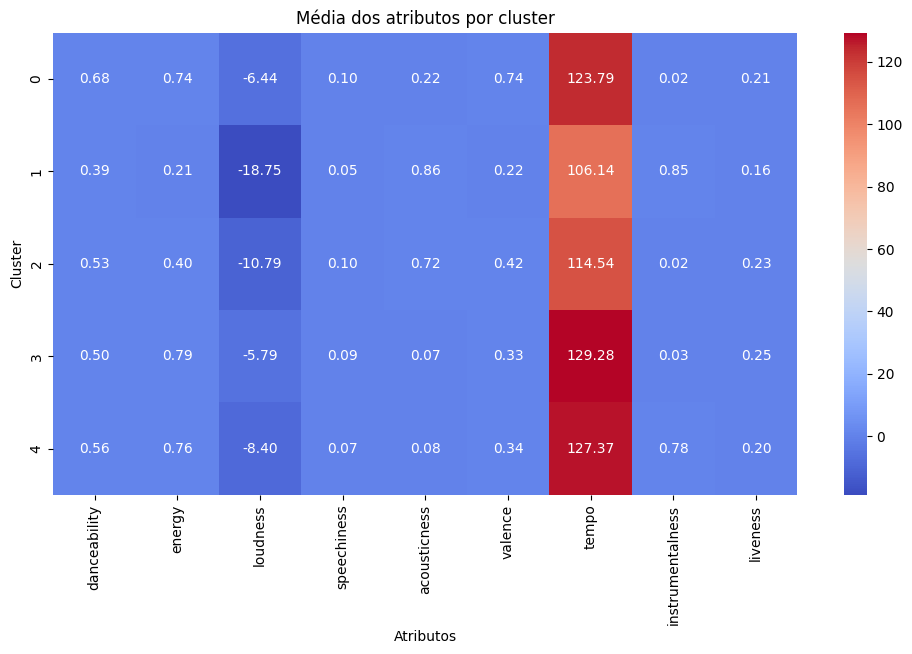

In [8]:
mean_values = df.groupby('cluster')[CLUSTER_FEATURES].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(mean_values, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Média dos atributos por cluster")
plt.ylabel("Cluster")
plt.xlabel("Atributos")
plt.show()

# Shap dos Clusters

In [ ]:
X = df[CLUSTER_FEATURES]
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)
n_clusters = len(set(y))


# === SUMMARY PLOTS POR CLUSTER ===
for i in range(n_clusters):
    print(f"\nCluster {i}")
    shap.summary_plot(shap_values[..., i], X_test, show=True)



print("\nWaterfall plots por cluster:")
for i in range(n_clusters):
    idx = np.where(y_test.values == i)[0]
    if len(idx) == 0:
        continue  # pula se não tiver exemplo desse cluster no X_test
    sample_idx = idx[0]

    print(f"\nCluster {i} - Amostra índice {sample_idx}")
    shap.plots.waterfall(shap_values[sample_idx, :, i])

  3%|=                   | 4040/142352 [08:38<295:34]       